In [ ]:
# KU Leuven Hydraulic Structures course exercise
# Methodology by Tim Aertsens and Lars Spannan.
#
# Capytaine is used to compute the hydrodynamic coefficients and wave-excitation loads
# based on linear potential-flow theory.
#
# Capytaine documentation:
# https://capytaine.org/stable/
#
# Recommended Capytaine references:
# Ancellin and Dias (2019), Capytaine: a Python-based linear potential flow solver.
# Babarit and Delhommeau (2015), Theoretical and numerical aspects of the open source
# BEM solver NEMOH.

# ============================================================
# BLOCK 1 — Imports and helper functions
# ============================================================

import os
import logging
import subprocess
import numpy as np
import xarray as xr
import capytaine as cpt
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 8)

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:\t%(message)s"
)

cpt.set_logging("INFO")


def run_shell_command(command):
    """
    Run a shell command and print stdout/stderr.
    Raises RuntimeError if the command fails.
    """
    print(f"\nRunning command:\n{command}\n")

    result = subprocess.run(
        command,
        shell=True,
        text=True,
        capture_output=True
    )

    if result.stdout:
        print("STDOUT:")
        print(result.stdout)

    if result.stderr:
        print("STDERR:")
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(
            f"Command failed with return code {result.returncode}:\n{command}"
        )

    return result

In [ ]:
# ============================================================
# BLOCK 2 — User inputs
# ============================================================

# ----------------------------
# Input mesh
# ----------------------------
stl_file = "truncated_cylinder.stl"       # STL-file exported from Gmsh
mesh_file = "truncated_cylinder.mar"      # .mar file used my meshmagick
mesh_file_format = "nemoh"  # BEM solver format used by Capytaine

# ----------------------------
# Output folder
# ----------------------------
output_dir = "capytaine_single_unit_output"
os.makedirs(output_dir, exist_ok=True)

nc_output_file = os.path.join(output_dir, "single_unit_capytaine.nc")

hydrostatics_output_dir = os.path.join(output_dir, "hydrostatics")
os.makedirs(hydrostatics_output_dir, exist_ok=True)

# ----------------------------
# Fluid properties
# ----------------------------
rho = 1000.0
g = 9.81
water_depth = np.inf

# ----------------------------
# Floating body properties
# ----------------------------
# Center of gravity in mesh coordinates.
center_of_mass = np.array([0.0, 0.0, -7.5])

# Manual M mass values
m = 3203811.75

Ixx = 320381175.0
Iyy = 320381175.0
Izz = 320381175.0

Ixy = 0.0
Ixz = 0.0
Iyz = 0

# Buoyancy estimate from static values
# Capytaine calculates the hydrostatic stiffness matrix separately.
number_of_floaters = 1
D = 20
freeboard = 0.1         # 0 freeboard gives error in Capytaine, only submerged part is descritised
totalHeight = 10.1

draft = totalHeight - freeboard
r = D / 2.0

manual_displaced_volume = number_of_floaters * np.pi * r**2 * draft
manual_center_of_buoyancy = np.array([0.0, 0.0, -draft/2.0])

print("Estimated displaced volume [m^3]:", manual_displaced_volume)
print("Estimated center of buoyancy [m]:", manual_center_of_buoyancy)

# ----------------------------
# Frequency and wave heading range
# ----------------------------
T_range_1 = np.linspace(1.0, 8.0, 50, endpoint=False)
T_range_2 = np.linspace(8.0, 10.0, 100, endpoint=False)
T_range_3 = np.linspace(10.0, 14.0, 50)

T_range = np.concatenate([T_range_1, T_range_2, T_range_3])

# Convert period to angular frequency for Capytaine
omega_range = 2.0 * np.pi / T_range

# Optional: sort by increasing omega, useful for clean dataset ordering
sort_idx = np.argsort(omega_range)
omega_range = omega_range[sort_idx]
T_range = T_range[sort_idx]

# One wave direction for first test
wave_direction_range = np.array([np.deg2rad(0.0)])

print("Number of periods/frequencies:", len(omega_range))
print("Minimum period [s]:", np.min(T_range))
print("Maximum period [s]:", np.max(T_range))
print("Dense period region: 8–10 s")

Estimated displaced volume [m^3]: 3141.5926535897934
Estimated center of buoyancy [m]: [ 0.  0. -5.]
Number of periods/frequencies: 200
Minimum period [s]: 1.0
Maximum period [s]: 14.0
Dense period region: 8–10 s


In [ ]:
# ============================================================
# BLOCK 3 — Convert STL to MAR using Meshmagick
# ============================================================

if not os.path.isfile(stl_file):
    raise FileNotFoundError(f"Could not find STL file: {stl_file}")

run_shell_command(f"meshmagick -o {mesh_file} {stl_file}")

if not os.path.isfile(mesh_file):
    raise FileNotFoundError(f"Meshmagick did not create: {mesh_file}")

print(f"Created MAR mesh file: {mesh_file}")


Running command:
meshmagick -o validation.mar validation.stl

STDOUT:

meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
validation.stl successfully loaded
Writing validation.mar
	-> Done.

Meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
Maintainer : Francois Rongere <Francois.Rongere@dice-engineering.com>
Good Bye!

Created MAR mesh file: validation.mar


In [ ]:
# ============================================================
# BLOCK 3B — Show single-unit mesh in Meshmagick
# ============================================================

run_shell_command(f"meshmagick --show {mesh_file}")


Running command:
meshmagick --show validation.mar

STDOUT:

meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
validation.mar successfully loaded

Meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
Maintainer : Francois Rongere <Francois.Rongere@dice-engineering.com>
Good Bye!



CompletedProcess(args='meshmagick --show validation.mar', returncode=0, stdout='\n=============================================\nmeshmagick - version 3.4\nCopyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering\n=============================================\nvalidation.mar successfully loaded\n\n=============================================================\nMeshmagick - version 3.4\nCopyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering\nMaintainer : Francois Rongere <Francois.Rongere@dice-engineering.com>\nGood Bye!\n=============================================================\n', stderr='')

In [ ]:
# ============================================================
# BLOCK 4 — Load single body mesh
# ============================================================

body = cpt.FloatingBody.from_file(
    mesh_file,
    file_format=mesh_file_format,
    name="single_unit"
)

body.center_of_mass = center_of_mass
body.rotation_center = center_of_mass

print(body)


[14:29:19] INFO     New floating body: FloatingBody(mesh=Mesh(..., name="single_unit_mesh"), lid_mesh=None,        
                    dofs={}, name="single_unit").

FloatingBody(mesh=Mesh(..., name="single_unit_mesh"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -7.5], name="single_unit")


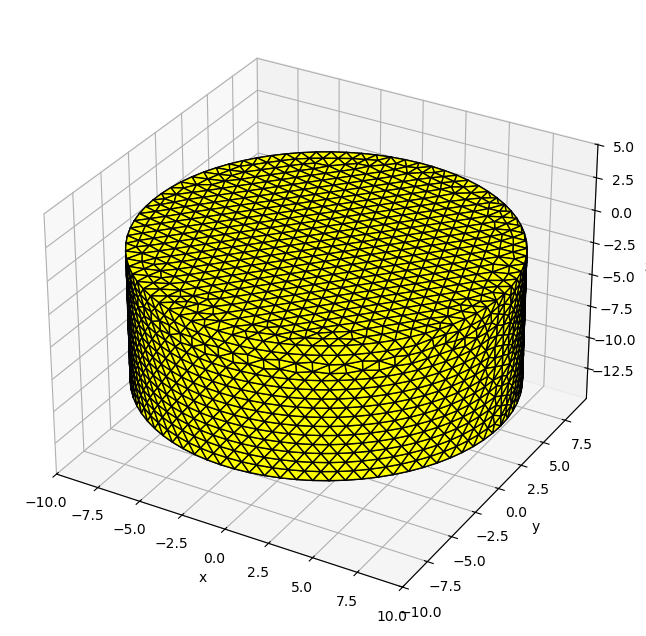

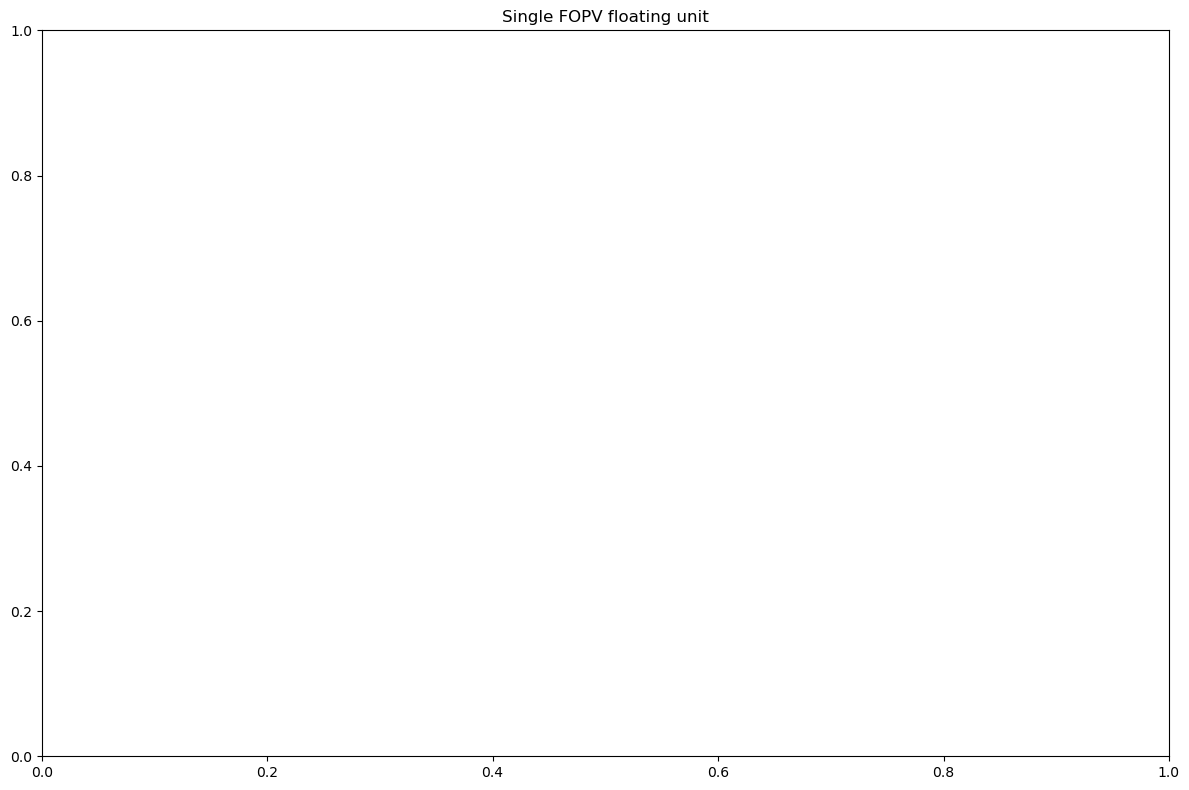

In [ ]:
# ============================================================
# BLOCK 5 — Visualize single body mesh in Python
# ============================================================

body.show_matplotlib()
plt.title("Single FOPV floating unit")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "single_unit_mesh.png"), dpi=300)
plt.show()

In [ ]:
# ============================================================
# BLOCK 6 — Manual rigid-body inertia matrix
# ============================================================

import numpy as np
import xarray as xr

dof_names = ["Surge", "Sway", "Heave", "Roll", "Pitch", "Yaw"]


def make_manual_inertia_matrix(mass, Ixx, Iyy, Izz, Ixy=0.0, Ixz=0.0, Iyz=0.0):
    """
    Create a 6x6 rigid-body inertia matrix.

    DOF order:
    Surge, Sway, Heave, Roll, Pitch, Yaw
    """

    M = np.zeros((6, 6))

    # Translational mass terms
    M[0, 0] = mass
    M[1, 1] = mass
    M[2, 2] = mass

    # Rotational inertia terms
    M[3, 3] = Ixx
    M[4, 4] = Iyy
    M[5, 5] = Izz

    # Products of inertia
    M[3, 4] = Ixy
    M[4, 3] = Ixy

    M[3, 5] = Ixz
    M[5, 3] = Ixz

    M[4, 5] = Iyz
    M[5, 4] = Iyz

    return xr.DataArray(
        M,
        dims=("influenced_dof", "radiating_dof"),
        coords={
            "influenced_dof": dof_names,
            "radiating_dof": dof_names,
        },
        name="inertia_matrix",
    )


body.inertia_matrix = make_manual_inertia_matrix(
    m,
    Ixx,
    Iyy,
    Izz,
    Ixy,
    Ixz,
    Iyz,
)

print("Manual inertia matrix:")
print(body.inertia_matrix)

Manual inertia matrix:
<xarray.DataArray 'inertia_matrix' (influenced_dof: 6, radiating_dof: 6)> Size: 288B
array([[3.20381175e+06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 3.20381175e+06, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 3.20381175e+06, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.20381175e+08,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        3.20381175e+08, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 3.20381175e+08]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 120B 'Surge' 'Sway' ... 'Pitch' 'Yaw'
  * radiating_dof   (radiating_dof) <U5 120B 'Surge' 'Sway' ... 'Pitch' 'Yaw'


In [ ]:
# ============================================================
# BLOCK 7 — Hydrostatic stiffness from Capytaine
# ============================================================

body_immersed = body.keep_immersed_part(inplace=False)


body_immersed.center_of_mass = body.center_of_mass
body_immersed.rotation_center = body.rotation_center
body_immersed.inertia_matrix = body.inertia_matrix
#IMPORTANT add DOFS after keep_immersed
body_immersed.dofs = {}
body_immersed.add_all_rigid_body_dofs()

print("Final immersed mesh faces:", body_immersed.mesh.nb_faces)
print("DOF shapes:")
for dof_name, dof in body_immersed.dofs.items():
    print(f"{dof_name}: {dof.shape}")

body_immersed._check_dofs_shape_consistency()
print("DOF check passed.")

body_immersed.hydrostatic_stiffness = body_immersed.compute_hydrostatic_stiffness(
    rho=rho,
    g=g
)

print("Hydrostatic stiffness matrix from Capytaine:")
with np.printoptions(precision=6, suppress=True):
    print(body_immersed.hydrostatic_stiffness.to_numpy())

[14:29:20] INFO     Clipping copy_of_single_unit with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])

           INFO     The rotation dof Roll has been initialized around the point: FloatingBody(...,                 
                    name="copy_of_single_unit").rotation_center = [ 0.   0.  -7.5]

           INFO     The rotation dof Pitch has been initialized around the point: FloatingBody(...,                
                    name="copy_of_single_unit").rotation_center = [ 0.   0.  -7.5]

           INFO     The rotation dof Yaw has been initialized around the point: FloatingBody(...,                  
                    name="copy_of_single_unit").rotation_center = [ 0.   0.  -7.5]

Final immersed mesh faces: 3581
DOF shapes:
Surge: (3581, 3)
Sway: (3581, 3)
Heave: (3581, 3)
Roll: (3581, 3)
Pitch: (3581, 3)
Yaw: (3581, 3)
DOF check passed.
Hydrostatic stiffness matrix from Capytaine:
[[ 0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
   0.000000e+00]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
   0.000000e+00]
 [ 0.000000e+00  0.000000e+00  3.079316e+06  2.099780e+02  3.183761e+02
   0.000000e+00]
 [ 0.000000e+00  0.000000e+00  2.099780e+02  1.538231e+08  7.948947e+02
  -2.006703e+03]
 [ 0.000000e+00  0.000000e+00  3.183761e+02  7.948947e+02  1.538238e+08
  -7.483305e+01]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
   0.000000e+00]]


In [ ]:
# ============================================================
# BLOCK 8 — Print and save inertia/hydrostatic matrices
# ============================================================

def print_xarray_matrix(matrix, title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    print("Rows:")
    print(list(matrix.coords["influenced_dof"].values))

    print("Columns:")
    print(list(matrix.coords["radiating_dof"].values))

    with np.printoptions(precision=6, suppress=True, linewidth=200):
        print(matrix.to_numpy())


print_xarray_matrix(
    body_immersed.inertia_matrix,
    "SINGLE-UNIT MANUAL INERTIA MATRIX"
)

print_xarray_matrix(
    body_immersed.hydrostatic_stiffness,
    "SINGLE-UNIT HYDROSTATIC STIFFNESS MATRIX"
)

np.savetxt(
    os.path.join(output_dir, "single_unit_inertia_matrix.txt"),
    body_immersed.inertia_matrix.to_numpy(),
    fmt="%.10e",
)

np.savetxt(
    os.path.join(output_dir, "single_unit_hydrostatic_stiffness.txt"),
    body_immersed.hydrostatic_stiffness.to_numpy(),
    fmt="%.10e",
)

print("Saved matrix text files in:", output_dir)


SINGLE-UNIT MANUAL INERTIA MATRIX
Rows:
[np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np.str_('Yaw')]
Columns:
[np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np.str_('Yaw')]
[[3.203812e+06 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 3.203812e+06 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 3.203812e+06 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 3.203812e+08 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 3.203812e+08 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 3.203812e+08]]

SINGLE-UNIT HYDROSTATIC STIFFNESS MATRIX
Rows:
[np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np.str_('Yaw')]
Columns:
[np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np

In [ ]:
# ============================================================
# BLOCK 9 — Solve single-body BEM problem
# ============================================================

test_matrix = xr.Dataset(
    coords={
        "omega": omega_range,
        "wave_direction": wave_direction_range,
        "radiating_dof": list(body_immersed.dofs.keys()),
        "water_depth": [water_depth],
        "rho": [rho],
        "g": [g],
    }
)

solver = cpt.BEMSolver()

dataset = solver.fill_dataset(test_matrix, body_immersed)

print(dataset)

           INFO     Loading tabulation from                                                                        
                    C:\Users\deniz\AppData\Local\capytaine\Cache\2.3.1\tabulation_float64_scaled_nemoh3_676_100.0_3
                    72_-251.0_1001.npz

[14:29:21] WARNING  Mesh resolution for 42 problems:                                                               
                    The resolution of the mesh might be insufficient for omega ranging from 3.696 to 6.283.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

           WARNING  Irregular frequencies for 161 problems:                                                        
                    Irregular frequencies might be encountered for omega ranging from 1.540 to 6.283.              
                    Setting a lid for the floating body is recommended.

c:\Users\deniz\anaconda3\envs\capytaine_new\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

           INFO     Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_single_unit"), omega=0.449,      
                    water_depth=inf, wave_direction=0.000).

...

           INFO     Solve RadiationProblem(body=FloatingBody(..., name="copy_of_single_unit"), omega=6.283,        
                    water_depth=inf, radiating_dof='Roll').

           INFO     Solve RadiationProblem(body=FloatingBody(..., name="copy_of_single_unit"), omega=6.283,        
                    water_depth=inf, radiating_dof='Pitch').

           INFO     Solve RadiationProblem(body=FloatingBody(..., name="copy_of_single_unit"), omega=6.283,        
                    water_depth=inf, radiating_dof='Yaw').

           INFO     Solver timer summary:                                                                          
                                           total  nb_calls      mean                                               
                    task                                                                                           
                    Solve total       418.904334      1400  0.299217                                               
                      Green function  207.719692      1400  0.148371                                               
                      Linear solver   181.449017      1400  0.129606

<xarray.Dataset> Size: 182kB
Dimensions:                (omega: 200, radiating_dof: 6, influenced_dof: 6,
                            wave_direction: 1)
Coordinates: (12/13)
  * omega                  (omega) float64 2kB 0.4488 0.4514 ... 5.512 6.283
    freq                   (omega) float64 2kB 0.07143 0.07185 ... 0.8772 1.0
    period                 (omega) float64 2kB 14.0 13.92 13.84 ... 1.14 1.0
    wavenumber             (omega) float64 2kB 0.02053 0.02077 ... 3.097 4.024
    wavelength             (omega) float64 2kB 306.0 302.5 298.9 ... 2.029 1.561
  * radiating_dof          (radiating_dof) category 54B Surge Sway ... Pitch Yaw
    ...                     ...
  * wave_direction         (wave_direction) float64 8B 0.0
    g                      float64 8B 9.81
    rho                    float64 8B 1e+03
    body_name              StringDType(na_object=nan) 16B 'copy_of_single_unit'
    water_depth            float64 8B inf
    forward_speed          float64 8B 0.0
Data variab

In [ ]:
# ============================================================
# BLOCK 10 — Add metadata for BEMIO/WEC-Sim
# ============================================================

dataset["inertia_matrix"] = body_immersed.inertia_matrix
dataset["hydrostatic_stiffness"] = body_immersed.hydrostatic_stiffness

dataset["center_of_mass"] = (
    ["point_coordinates"],
    np.array(center_of_mass, dtype=float),
)

dataset["center_of_buoyancy"] = (
    ["point_coordinates"],
    np.array(manual_center_of_buoyancy, dtype=float),
)

dataset["volume"] = (
    [],
    float(manual_displaced_volume),
)

print("Added metadata:")
print("  inertia_matrix")
print("  hydrostatic_stiffness")
print("  center_of_mass")
print("  center_of_buoyancy")
print("  volume")

print(dataset)

Added metadata:
  inertia_matrix
  hydrostatic_stiffness
  center_of_mass
  center_of_buoyancy
  volume
<xarray.Dataset> Size: 182kB
Dimensions:                (omega: 200, radiating_dof: 6, influenced_dof: 6,
                            wave_direction: 1, point_coordinates: 3)
Coordinates: (12/13)
  * omega                  (omega) float64 2kB 0.4488 0.4514 ... 5.512 6.283
    freq                   (omega) float64 2kB 0.07143 0.07185 ... 0.8772 1.0
    period                 (omega) float64 2kB 14.0 13.92 13.84 ... 1.14 1.0
    wavenumber             (omega) float64 2kB 0.02053 0.02077 ... 3.097 4.024
    wavelength             (omega) float64 2kB 306.0 302.5 298.9 ... 2.029 1.561
  * radiating_dof          (radiating_dof) <U5 120B 'Surge' 'Sway' ... 'Yaw'
    ...                     ...
  * wave_direction         (wave_direction) float64 8B 0.0
    g                      float64 8B 9.81
    rho                    float64 8B 1e+03
    body_name              StringDType(na_object=nan)

In [ ]:
# ============================================================
# BLOCK 11 — Check hydrodynamic data needed by WEC-Sim/BEMIO
# ============================================================

required_variables = [
    "added_mass",
    "radiation_damping",
    "diffraction_force",
    "Froude_Krylov_force",
]

print("\n" + "=" * 80)
print("CHECKING CAPYTAINE DATASET FOR WEC-SIM/BEMIO")
print("=" * 80)

print("\nDataset variables:")
for var in dataset.data_vars:
    print("  ", var)

print("\nRequired variables check:")
for var in required_variables:
    if var in dataset:
        print(f"  OK: {var}, shape = {dataset[var].shape}")
    else:
        print(f"  MISSING: {var}")

print("\nDataset coordinates:")
for coord in dataset.coords:
    print(f"  {coord}: {dataset.coords[coord].shape}")

print("\nRadiating DOFs:")
for dof in dataset.coords["radiating_dof"].values:
    print("  ", dof)

print("\nInfluenced DOFs:")
for dof in dataset.coords["influenced_dof"].values:
    print("  ", dof)


CHECKING CAPYTAINE DATASET FOR WEC-SIM/BEMIO

Dataset variables:
   added_mass
   radiation_damping
   diffraction_force
   Froude_Krylov_force
   excitation_force
   inertia_matrix
   hydrostatic_stiffness
   center_of_mass
   center_of_buoyancy
   volume

Required variables check:
  OK: added_mass, shape = (200, 6, 6)
  OK: radiation_damping, shape = (200, 6, 6)
  OK: diffraction_force, shape = (200, 1, 6)
  OK: Froude_Krylov_force, shape = (200, 1, 6)

Dataset coordinates:
  g: ()
  rho: ()
  body_name: ()
  water_depth: ()
  forward_speed: ()
  wave_direction: (1,)
  omega: (200,)
  radiating_dof: (6,)
  influenced_dof: (6,)
  freq: (200,)
  period: (200,)
  wavenumber: (200,)
  wavelength: (200,)

Radiating DOFs:
   Surge
   Sway
   Heave
   Roll
   Pitch
   Yaw

Influenced DOFs:
   Surge
   Sway
   Heave
   Roll
   Pitch
   Yaw


In [ ]:
# ============================================================
# BLOCK 12 — Export Capytaine NetCDF
# ============================================================

cpt.export_dataset(nc_output_file, dataset, format="netcdf")

print("Saved Capytaine NetCDF file:")
print(nc_output_file)

Saved Capytaine NetCDF file:
capytaine_single_unit_output\single_unit_capytaine.nc


In [ ]:
# ============================================================
# BLOCK 13 — Write Hydrostatics.dat and KH.dat for BEMIO
# ============================================================

def write_hydrostatics_dat(filename, center_of_buoyancy, center_of_gravity, displaced_volume):
    """
    Write Hydrostatics.dat in the Nemoh-style format expected by WEC-Sim BEMIO.
    """

    cb = np.asarray(center_of_buoyancy, dtype=float)
    cg = np.asarray(center_of_gravity, dtype=float)

    with open(filename, "w") as f:
        f.write(f"CB x {cb[0]:.10e} CG = x {cg[0]:.10e}\n")
        f.write(f"CB y {cb[1]:.10e} CG = y {cg[1]:.10e}\n")
        f.write(f"CB z {cb[2]:.10e} CG = z {cg[2]:.10e}\n")
        f.write(f"Volume = {float(displaced_volume):.10e}\n")


def write_kh_dat(filename, kh_matrix):
    """
    Write KH.dat as 6 rows x 6 columns.
    """

    kh = np.asarray(kh_matrix, dtype=float)

    if kh.shape != (6, 6):
        raise ValueError(f"KH matrix must be 6x6. Got shape {kh.shape}")

    with open(filename, "w") as f:
        for i in range(6):
            row = " ".join(f"{kh[i, j]:.10e}" for j in range(6))
            f.write(row + "\n")


hydrostatics_dat_file = os.path.join(hydrostatics_output_dir, "Hydrostatics.dat")
kh_dat_file = os.path.join(hydrostatics_output_dir, "KH.dat")

write_hydrostatics_dat(
    hydrostatics_dat_file,
    manual_center_of_buoyancy,
    center_of_mass,
    manual_displaced_volume,
)

write_kh_dat(
    kh_dat_file,
    body_immersed.hydrostatic_stiffness.to_numpy(),
)

print("Saved hydrostatics files:")
print(hydrostatics_dat_file)
print(kh_dat_file)

print("\nHydrostatics output folder contents:")
for file in os.listdir(hydrostatics_output_dir):
    print("  ", file)

Saved hydrostatics files:
capytaine_single_unit_output\hydrostatics\Hydrostatics.dat
capytaine_single_unit_output\hydrostatics\KH.dat

Hydrostatics output folder contents:
   Hydrostatics.dat
   KH.dat


In [ ]:
# ============================================================
# BLOCK 14 — Prepare files for WEC-Sim/BEMIO
# ============================================================

import shutil

bemio_ready_dir = os.path.join(output_dir, "hydroData_for_WEC_Sim")
os.makedirs(bemio_ready_dir, exist_ok=True)

# Copy Capytaine NetCDF
shutil.copyfile(
    nc_output_file,
    os.path.join(bemio_ready_dir, "single_unit_capytaine.nc")
)

# Copy hydrostatics files directly next to .nc
shutil.copyfile(
    hydrostatics_dat_file,
    os.path.join(bemio_ready_dir, "Hydrostatics.dat")
)

shutil.copyfile(
    kh_dat_file,
    os.path.join(bemio_ready_dir, "KH.dat")
)

print("Prepared BEMIO-ready hydroData folder:")
print(bemio_ready_dir)

print("\nFiles:")
for file in os.listdir(bemio_ready_dir):
    print("  ", file)

Prepared BEMIO-ready hydroData folder:
capytaine_single_unit_output\hydroData_for_WEC_Sim

Files:
   Hydrostatics.dat
   KH.dat
   single_unit_capytaine.nc


In [ ]:
# ============================================================
# BLOCK 15 — Compute RAOs
# ============================================================

from capytaine.post_pro import rao

selected_wave_direction = wave_direction_range[0]

rao_dataset = rao(
    dataset,
    wave_direction=selected_wave_direction,
)

print("\n" + "=" * 80)
print("RAO DATASET")
print("=" * 80)
print(rao_dataset)

           INFO     Compute RAO.


RAO DATASET
<xarray.DataArray (omega: 200, radiating_dof: 6)> Size: 19kB
array([[-8.38121436e-04+9.33633264e-01j, -2.15484113e-04-5.22304466e-05j,
         1.05579298e+00+9.05232433e-04j,  1.32861968e-05+7.55130568e-06j,
         3.20684128e-05-3.40378895e-02j,  3.31104920e-07+8.09967536e-08j],
       [-8.83421271e-04+9.33544599e-01j, -2.14716662e-04-5.21827405e-05j,
         1.05734302e+00+9.59143514e-04j,  1.35555174e-05+7.76914990e-06j,
         3.44571603e-05-3.47510019e-02j,  3.30386000e-07+8.20549330e-08j],
       [-9.32215854e-04+9.33479906e-01j, -2.13731140e-04-5.21309884e-05j,
         1.05894959e+00+1.01618615e-03j,  1.38429725e-05+7.99759859e-06j,
         3.70692834e-05-3.54915524e-02j,  3.29662350e-07+8.33471643e-08j],
       ...,
       [-3.27761969e-05-3.33288194e-04j, -6.06784683e-06-8.73098564e-06j,
        -6.75581328e-06-9.30046584e-06j,  4.92773984e-07+5.36439911e-07j,
        -3.17184025e-06-2.77912048e-05j,  5.55487337e-11-1.95055060e-09j],
       [-1.88520770e-0

Available RAO DOFs:
   Surge
   Sway
   Heave
   Roll
   Pitch
   Yaw


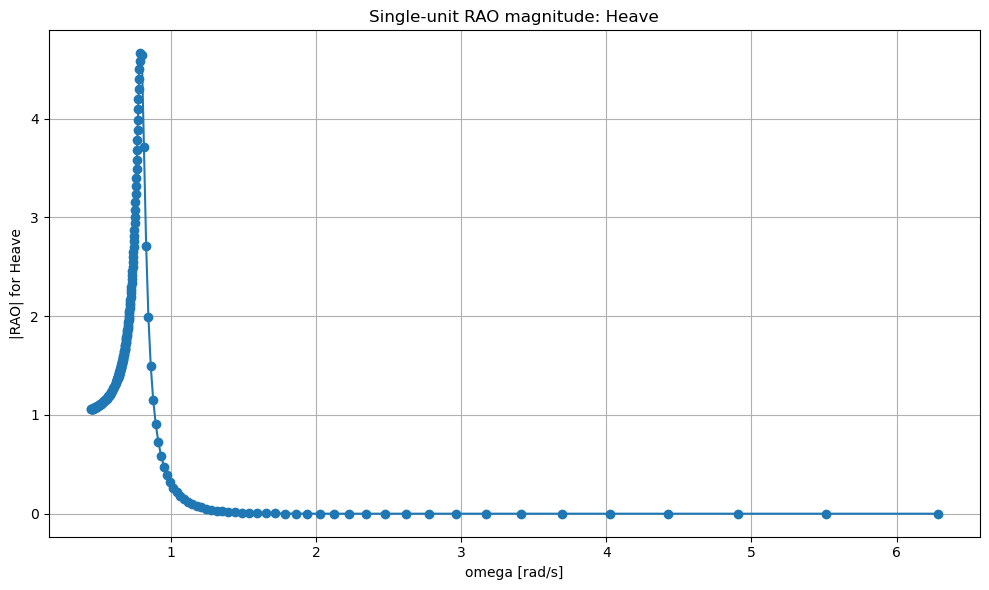

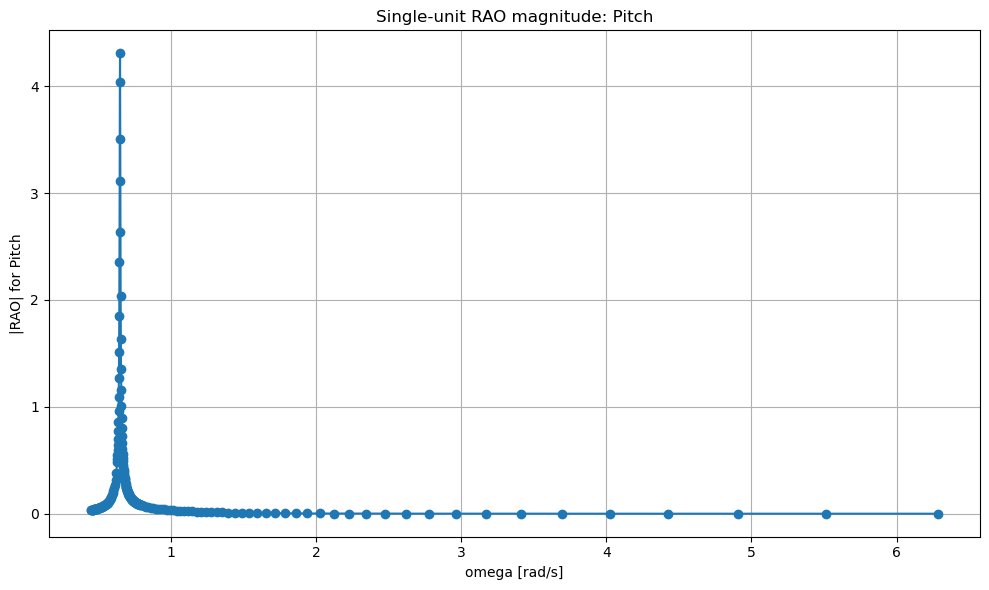

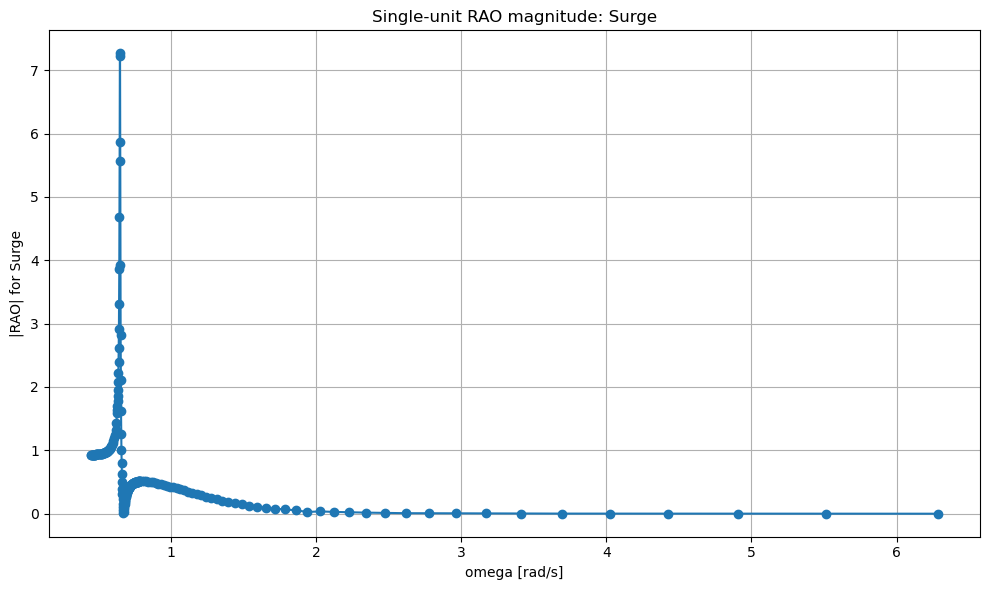

In [ ]:
# ============================================================
# BLOCK 16 — Plot RAO magnitudes
# ============================================================

def get_rao_variable(rao_data):
    if isinstance(rao_data, xr.Dataset):
        if "rao" in rao_data:
            return rao_data["rao"]
        elif "RAO" in rao_data:
            return rao_data["RAO"]
        else:
            raise KeyError(f"Could not find RAO variable. Available variables: {list(rao_data.data_vars)}")
    return rao_data


def plot_rao_magnitude(rao_data, dof_name, output_filename=None):
    rao_values = get_rao_variable(rao_data)

    selected = rao_values.sel(radiating_dof=dof_name).squeeze()

    plt.figure(figsize=(10, 6))
    plt.plot(dataset["omega"], np.abs(selected), marker="o")
    plt.xlabel("omega [rad/s]")
    plt.ylabel(f"|RAO| for {dof_name}")
    plt.title(f"Single-unit RAO magnitude: {dof_name}")
    plt.grid(True)
    plt.tight_layout()

    if output_filename is not None:
        plt.savefig(os.path.join(output_dir, output_filename), dpi=300)

    plt.show()


print("Available RAO DOFs:")
rao_values_check = get_rao_variable(rao_dataset)
for dof in rao_values_check["radiating_dof"].values:
    print("  ", dof)

plot_rao_magnitude(rao_dataset, "Heave", "rao_single_unit_heave.png")
plot_rao_magnitude(rao_dataset, "Pitch", "rao_single_unit_pitch.png")
plot_rao_magnitude(rao_dataset, "Surge", "rao_single_unit_surge.png")

In [ ]:
# ============================================================
# BLOCK 17 — Export hydrodynamic results to one Excel workbook
# ============================================================

import pandas as pd
import os
import numpy as np
import xarray as xr

excel_output_dir = os.path.join(output_dir, "excel_exports")
os.makedirs(excel_output_dir, exist_ok=True)


def complex_to_columns(df, value_column="value"):
    values = df[value_column].to_numpy()

    df[f"{value_column}_real"] = np.real(values)
    df[f"{value_column}_imag"] = np.imag(values)
    df[f"{value_column}_abs"] = np.abs(values)
    df[f"{value_column}_phase_rad"] = np.angle(values)
    df[f"{value_column}_phase_deg"] = np.angle(values, deg=True)

    return df.drop(columns=[value_column])


def dataarray_to_long_dataframe(da, quantity_name):
    df = da.to_dataframe(name="value").reset_index()
    df.insert(0, "quantity", quantity_name)

    # Optional convenience column: wave direction in degrees
    # This will stay 0 if your test_matrix only uses wave_direction = 0.
    if "wave_direction" in df.columns:
        df["wave_direction_deg"] = np.rad2deg(df["wave_direction"])

    if np.iscomplexobj(df["value"].to_numpy()):
        df = complex_to_columns(df, value_column="value")
    else:
        df = df.rename(columns={"value": "value_real"})
        df["value_imag"] = 0.0
        df["value_abs"] = np.abs(df["value_real"])
        df["value_phase_rad"] = 0.0
        df["value_phase_deg"] = 0.0

    return df


def get_rao_variable(rao_data):
    if isinstance(rao_data, xr.Dataset):
        if "rao" in rao_data:
            return rao_data["rao"]
        elif "RAO" in rao_data:
            return rao_data["RAO"]
        else:
            raise KeyError(
                f"Could not find RAO variable. Available variables: {list(rao_data.data_vars)}"
            )
    return rao_data


exports = {}

# ------------------------------------------------------------
# Hydrodynamic coefficients and forces
# ------------------------------------------------------------

variable_sheet_names = {
    "added_mass": "AddedMass",
    "radiation_damping": "RadiationDamping",
    "Froude_Krylov_force": "FroudeKrylov",
    "diffraction_force": "Diffraction",
}

for variable_name, sheet_name in variable_sheet_names.items():
    if variable_name in dataset:
        exports[sheet_name] = dataarray_to_long_dataframe(
            dataset[variable_name],
            variable_name
        )
    else:
        print(f"WARNING: {variable_name} not found in dataset.")


# ------------------------------------------------------------
# Total excitation force
# excitation = Froude-Krylov + diffraction
# ------------------------------------------------------------

if "Froude_Krylov_force" in dataset and "diffraction_force" in dataset:
    excitation_force = dataset["Froude_Krylov_force"] + dataset["diffraction_force"]
    excitation_force.name = "excitation_force"

    exports["Excitation"] = dataarray_to_long_dataframe(
        excitation_force,
        "excitation_force"
    )
else:
    print("WARNING: Could not compute excitation_force.")


# ------------------------------------------------------------
# RAO for 6 DOFs
# ------------------------------------------------------------

rao_values = get_rao_variable(rao_dataset)
rao_values.name = "RAO"

exports["RAO"] = dataarray_to_long_dataframe(
    rao_values,
    "RAO"
)


# ------------------------------------------------------------
# Optional combined sheet
# ------------------------------------------------------------

combined_df = pd.concat(exports.values(), ignore_index=True, sort=False)
exports["Combined"] = combined_df


# ------------------------------------------------------------
# Save one Excel workbook with separate tabs
# ------------------------------------------------------------

excel_file = os.path.join(
    excel_output_dir,
    "single_unit_hydrodynamic_results.xlsx"
)

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    for sheet_name, df in exports.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print("Excel workbook saved:")
print(excel_file)

print("\nSheets exported:")
for sheet_name in exports:
    print(f"- {sheet_name}")

print("\nPreview of combined sheet:")
display(combined_df.head(20))

Excel workbook saved:
capytaine_single_unit_output\excel_exports\single_unit_hydrodynamic_results.xlsx

Sheets exported:
- AddedMass
- RadiationDamping
- FroudeKrylov
- Diffraction
- Excitation
- RAO
- Combined

Preview of combined sheet:


,quantity,omega,radiating_dof,influenced_dof,g,rho,body_name,water_depth,forward_speed,freq,period,wavenumber,wavelength,value_real,value_imag,value_abs,value_phase_rad,value_phase_deg,wave_direction,wave_direction_deg
0,added_mass,0.448799,Surge,Surge,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,2.098041e+06,0.0,2.098041e+06,0.0,0.0,NaN,NaN
1,added_mass,0.448799,Surge,Sway,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,-2.551022e+01,0.0,2.551022e+01,0.0,0.0,NaN,NaN
2,added_mass,0.448799,Surge,Heave,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,1.320709e+02,0.0,1.320709e+02,0.0,0.0,NaN,NaN
3,added_mass,0.448799,Surge,Roll,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,3.231648e+02,0.0,3.231648e+02,0.0,0.0,NaN,NaN
4,added_mass,0.448799,Surge,Pitch,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,8.090853e+06,0.0,8.090853e+06,0.0,0.0,NaN,NaN
5,added_mass,0.448799,Surge,Yaw,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,1.064049e+01,0.0,1.064049e+01,0.0,0.0,NaN,NaN
6,added_mass,0.448799,Sway,Surge,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,-2.105393e+01,0.0,2.105393e+01,0.0,0.0,NaN,NaN
7,added_mass,0.448799,Sway,Sway,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,2.098416e+06,0.0,2.098416e+06,0.0,0.0,NaN,NaN
8,added_mass,0.448799,Sway,Heave,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,7.184571e+02,0.0,7.184571e+02,0.0,0.0,NaN,NaN
9,added_mass,0.448799,Sway,Roll,9.81,1000.0,copy_of_single_unit,inf,0.0,0.071429,14.0,0.020532,306.016758,-8.092183e+06,0.0,8.092183e+06,0.0,0.0,NaN,NaN


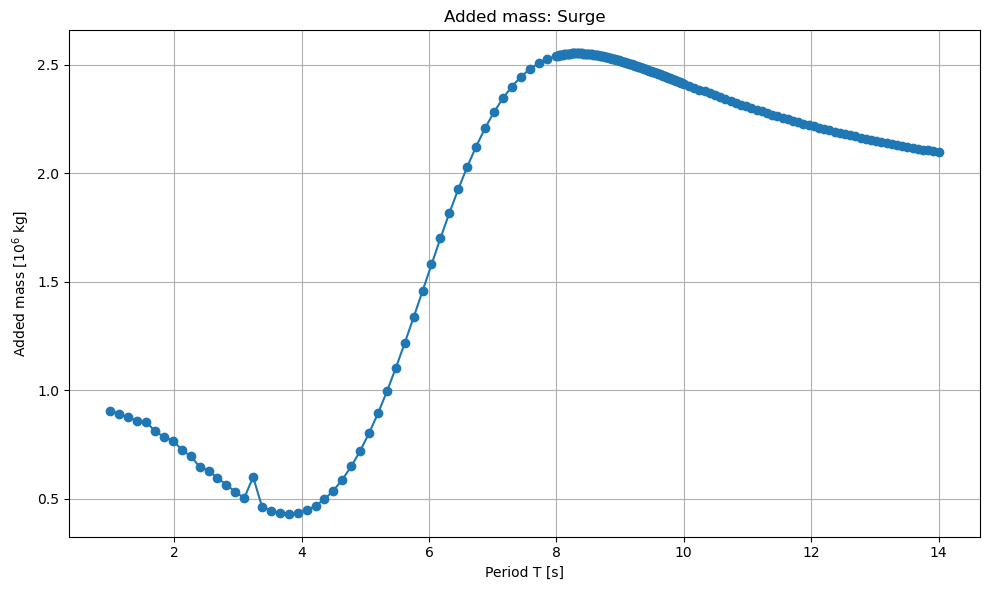

Saved: capytaine_single_unit_output\period_plots\added_mass_surge_vs_period.png


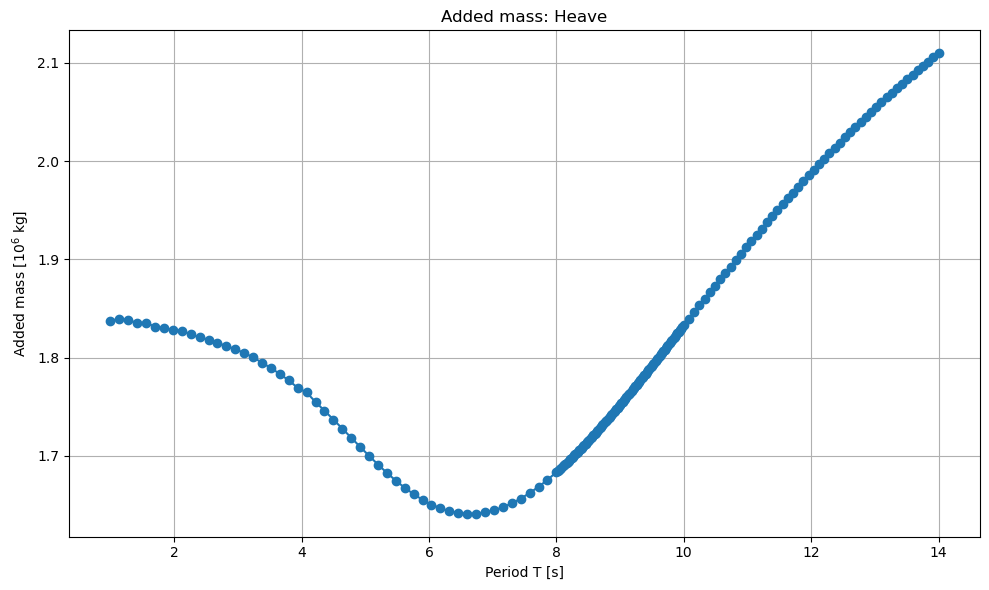

Saved: capytaine_single_unit_output\period_plots\added_mass_heave_vs_period.png


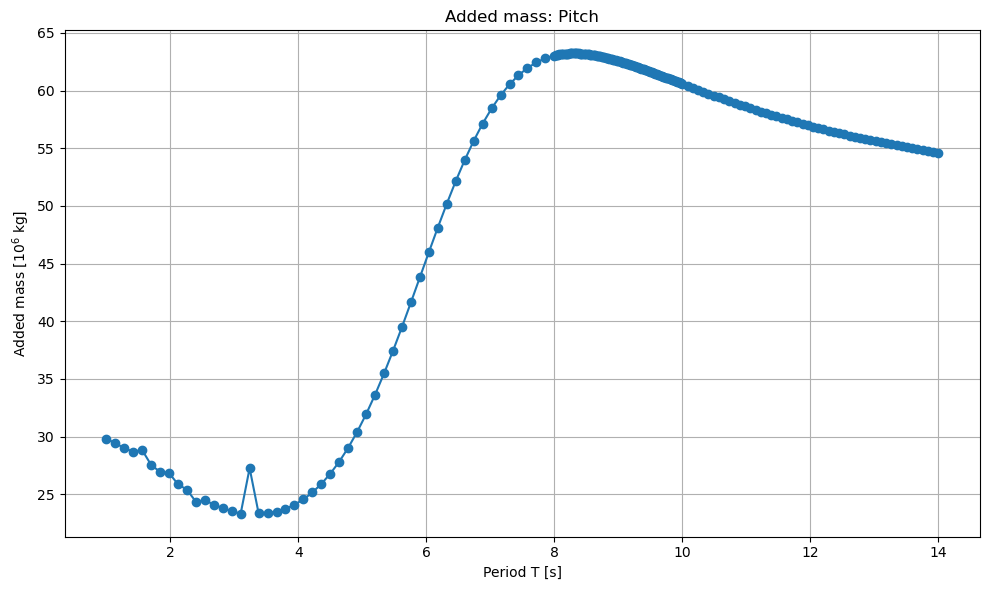

Saved: capytaine_single_unit_output\period_plots\added_mass_pitch_vs_period.png


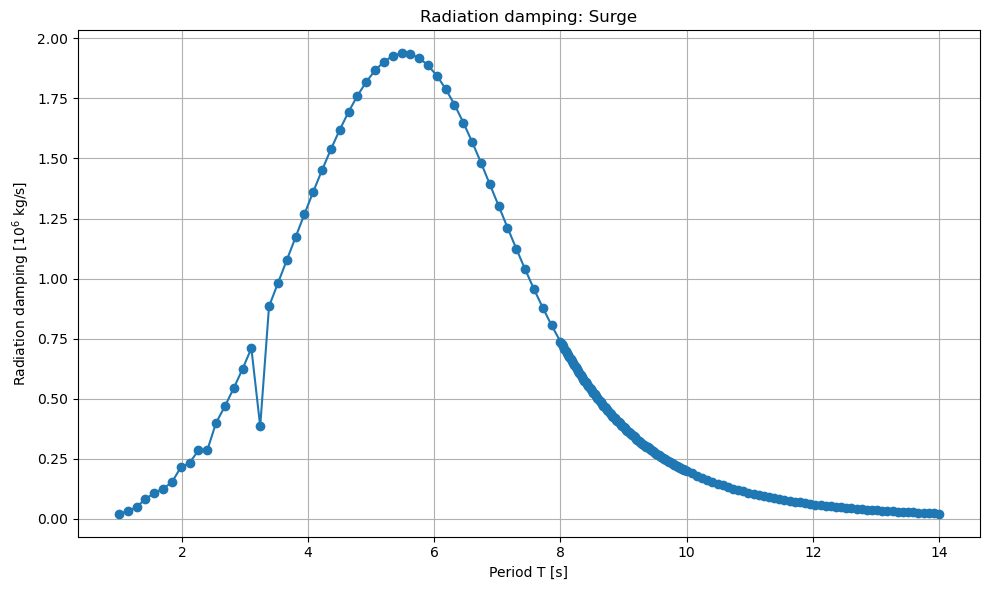

Saved: capytaine_single_unit_output\period_plots\radiation_damping_surge_vs_period.png


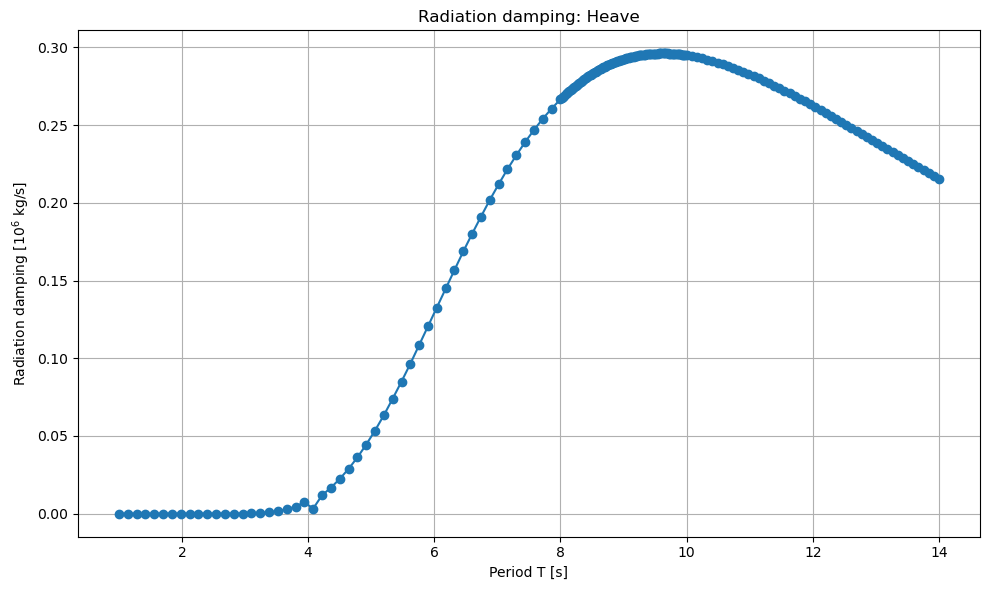

Saved: capytaine_single_unit_output\period_plots\radiation_damping_heave_vs_period.png


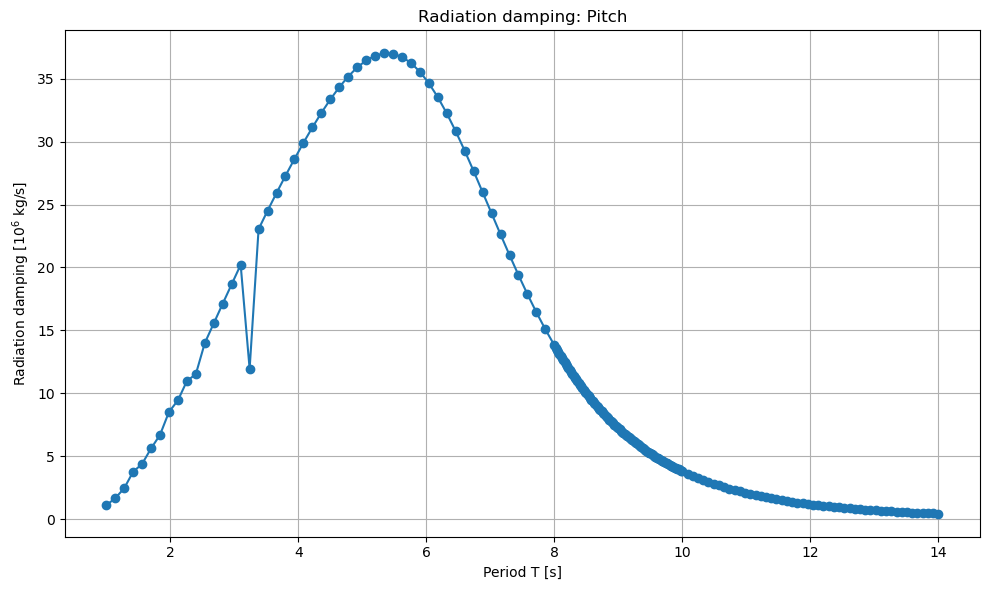

Saved: capytaine_single_unit_output\period_plots\radiation_damping_pitch_vs_period.png


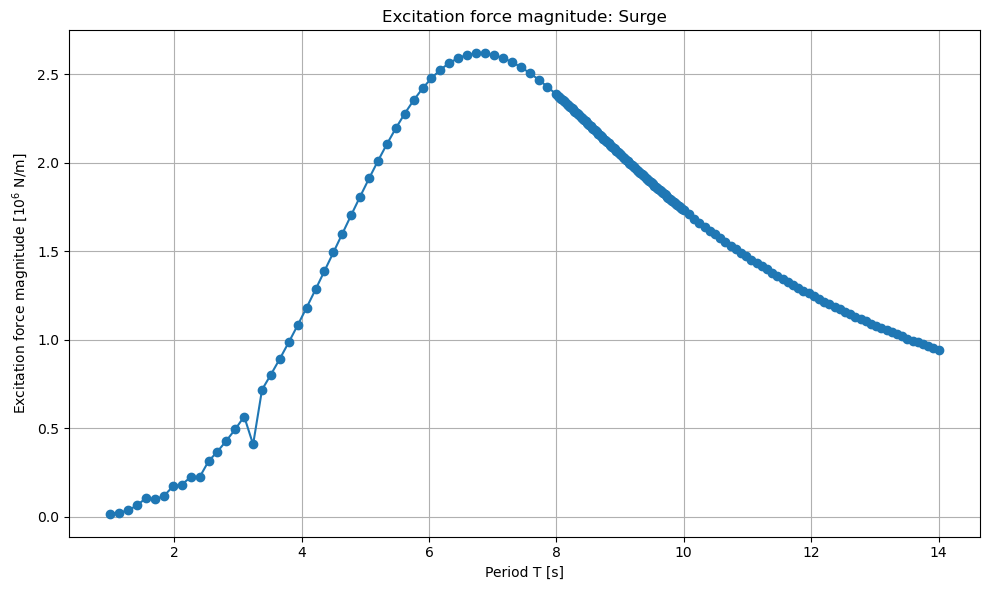

Saved: capytaine_single_unit_output\period_plots\excitation_force_surge_vs_period.png


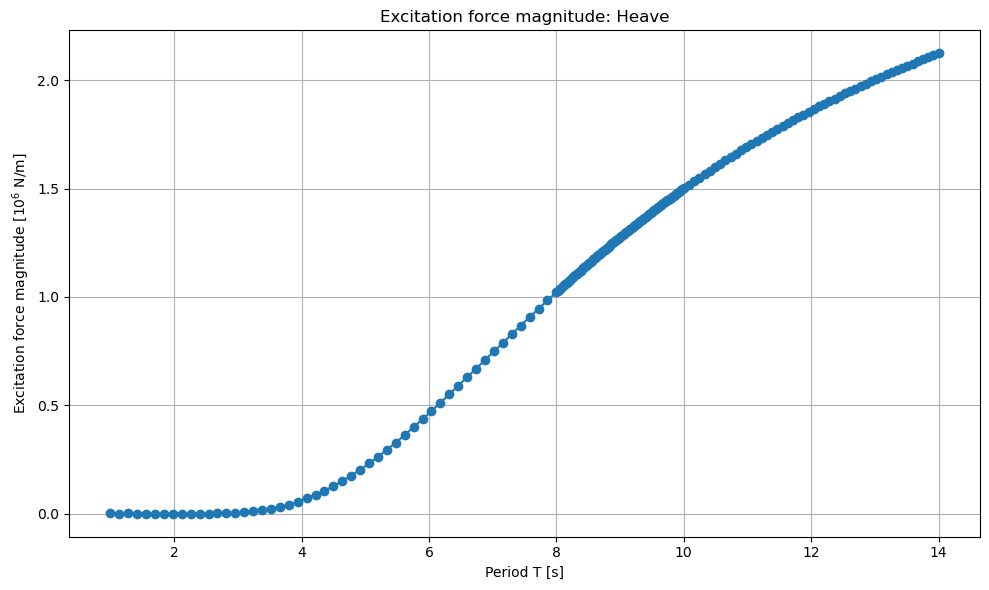

Saved: capytaine_single_unit_output\period_plots\excitation_force_heave_vs_period.png


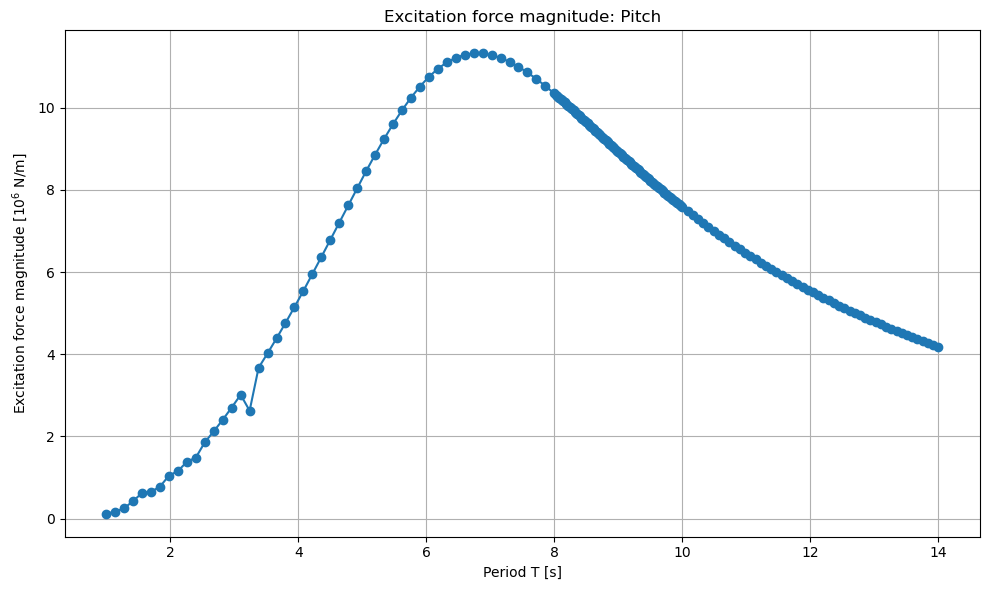

Saved: capytaine_single_unit_output\period_plots\excitation_force_pitch_vs_period.png


In [ ]:
# ============================================================
# BLOCK 18 — Plot added mass, radiation damping, and excitation force vs period
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# ----------------------------
# User settings
# ----------------------------
plot_dofs = ["Surge", "Heave", "Pitch"]   # Change this if needed

# Scaling factors for cleaner plots
# Example: 1e6 means the plotted value is original_value / 1e6
added_mass_scale = 1e6
radiation_damping_scale = 1e6
excitation_force_scale = 1e6

# Axis labels after scaling
added_mass_ylabel = r"Added mass [$10^6$ kg]"
radiation_damping_ylabel = r"Radiation damping [$10^6$ kg/s]"
excitation_force_ylabel = r"Excitation force magnitude [$10^6$ N/m]"

# Output folder
plot_output_dir = os.path.join(output_dir, "period_plots")
os.makedirs(plot_output_dir, exist_ok=True)


# ----------------------------
# Helper functions
# ----------------------------
def get_period_from_dataset(ds):
    """
    Return period array from dataset.
    Uses period directly if available, otherwise computes T = 2*pi/omega.
    """
    if "period" in ds.coords:
        period = ds["period"].values
    elif "period" in ds:
        period = ds["period"].values
    elif "omega" in ds.coords:
        period = 2.0 * np.pi / ds["omega"].values
    else:
        raise KeyError("Could not find period or omega in dataset.")

    return np.asarray(period, dtype=float)


def plot_hydro_quantity_vs_period(
    da,
    quantity_name,
    dofs,
    scale,
    ylabel,
    filename_prefix,
    use_diagonal_terms=True
):
    """
    Plot a hydrodynamic quantity against period.

    For added mass and radiation damping:
        use_diagonal_terms=True
        selected term = influenced_dof DOF, radiating_dof DOF

    For excitation force:
        use_diagonal_terms=False
        selected term = influenced_dof DOF
    """

    period = get_period_from_dataset(dataset)

    for dof in dofs:

        if use_diagonal_terms:
            selected = da.sel(
                influenced_dof=dof,
                radiating_dof=dof
            ).squeeze()
        else:
            selected = da.sel(
                influenced_dof=dof
            ).squeeze()

            # If wave_direction remains, select the first/only wave direction
            if "wave_direction" in selected.dims:
                selected = selected.isel(wave_direction=0)

        y = selected.values

        # Use magnitude for complex values, direct value for real values
        if np.iscomplexobj(y):
            y_plot = np.abs(y) / scale
        else:
            y_plot = np.asarray(y, dtype=float) / scale

        # Sort by increasing period
        sort_idx = np.argsort(period)
        period_sorted = period[sort_idx]
        y_sorted = y_plot[sort_idx]

        plt.figure(figsize=(10, 6))
        plt.plot(period_sorted, y_sorted, marker="o", linewidth=1.5)

        plt.xlabel("Period T [s]")
        plt.ylabel(ylabel)
        plt.title(f"{quantity_name}: {dof}")
        plt.grid(True)
        plt.tight_layout()

        output_file = os.path.join(
            plot_output_dir,
            f"{filename_prefix}_{dof.lower()}_vs_period.png"
        )

        plt.savefig(output_file, dpi=300)
        plt.show()

        print(f"Saved: {output_file}")


# ----------------------------
# Added mass vs period
# ----------------------------
if "added_mass" in dataset:
    plot_hydro_quantity_vs_period(
        da=dataset["added_mass"],
        quantity_name="Added mass",
        dofs=plot_dofs,
        scale=added_mass_scale,
        ylabel=added_mass_ylabel,
        filename_prefix="added_mass",
        use_diagonal_terms=True
    )
else:
    print("WARNING: added_mass not found in dataset.")


# ----------------------------
# Radiation damping vs period
# ----------------------------
if "radiation_damping" in dataset:
    plot_hydro_quantity_vs_period(
        da=dataset["radiation_damping"],
        quantity_name="Radiation damping",
        dofs=plot_dofs,
        scale=radiation_damping_scale,
        ylabel=radiation_damping_ylabel,
        filename_prefix="radiation_damping",
        use_diagonal_terms=True
    )
else:
    print("WARNING: radiation_damping not found in dataset.")


# ----------------------------
# Excitation force vs period
# excitation = Froude-Krylov + diffraction
# ----------------------------
if "Froude_Krylov_force" in dataset and "diffraction_force" in dataset:

    excitation_force = dataset["Froude_Krylov_force"] + dataset["diffraction_force"]
    excitation_force.name = "excitation_force"

    plot_hydro_quantity_vs_period(
        da=excitation_force,
        quantity_name="Excitation force magnitude",
        dofs=plot_dofs,
        scale=excitation_force_scale,
        ylabel=excitation_force_ylabel,
        filename_prefix="excitation_force",
        use_diagonal_terms=False
    )

else:
    print("WARNING: Could not compute excitation force.")